# Question 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predicting student scores using linear regression

## Step 1


### loading dataset & removing missing values

In [2]:
df=pd.read_csv('./Student_Performance.csv')

df_temp1=df.copy()
df_temp1=df_temp1.dropna()

print('missing values in df:\n',df.isna().sum())
print('missing values in df_temp1:\n',df_temp1.isna().sum())

missing values in df:
 Index                                0
Hours Studied                       10
Previous Scores                     10
Extracurricular Activities          10
Sleep Hours                         10
Sample Question Papers Practiced    10
Performance Index                    0
dtype: int64
missing values in df_temp1:
 Index                               0
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Index                             10000 non-null  int64  
 1   Hours Studied                     9990 non-null   float64
 2   Previous Scores                   9990 non-null   float64
 3   Extracurricular Activities        9990 non-null   object 
 4   Sleep Hours                       9990 non-null   float64
 5   Sample Question Papers Practiced  9990 non-null   float64
 6   Performance Index                 10000 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 547.0+ KB


### handling missing values and converting categorical values to numerical values

In [4]:

df['Extracurricular Activities']=pd.factorize(df['Extracurricular Activities'])[0]

# fill missing values with their mean

# columns=df.select_dtypes(include=np.number).columns
# for col in columns:
#     df[col].fillna(df[col].mean(),inplace=True)



# fill missing values with their mode

columns=df.select_dtypes(include=np.number).columns
for col in columns:
    df[col].fillna(df[col].mode()[0],inplace=True)

print(df.isna().sum())


Index                               0
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


/tmp/ipykernel_9747/4009888872.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)
/tmp/ipykernel_9747/4009888872.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

### ploting data

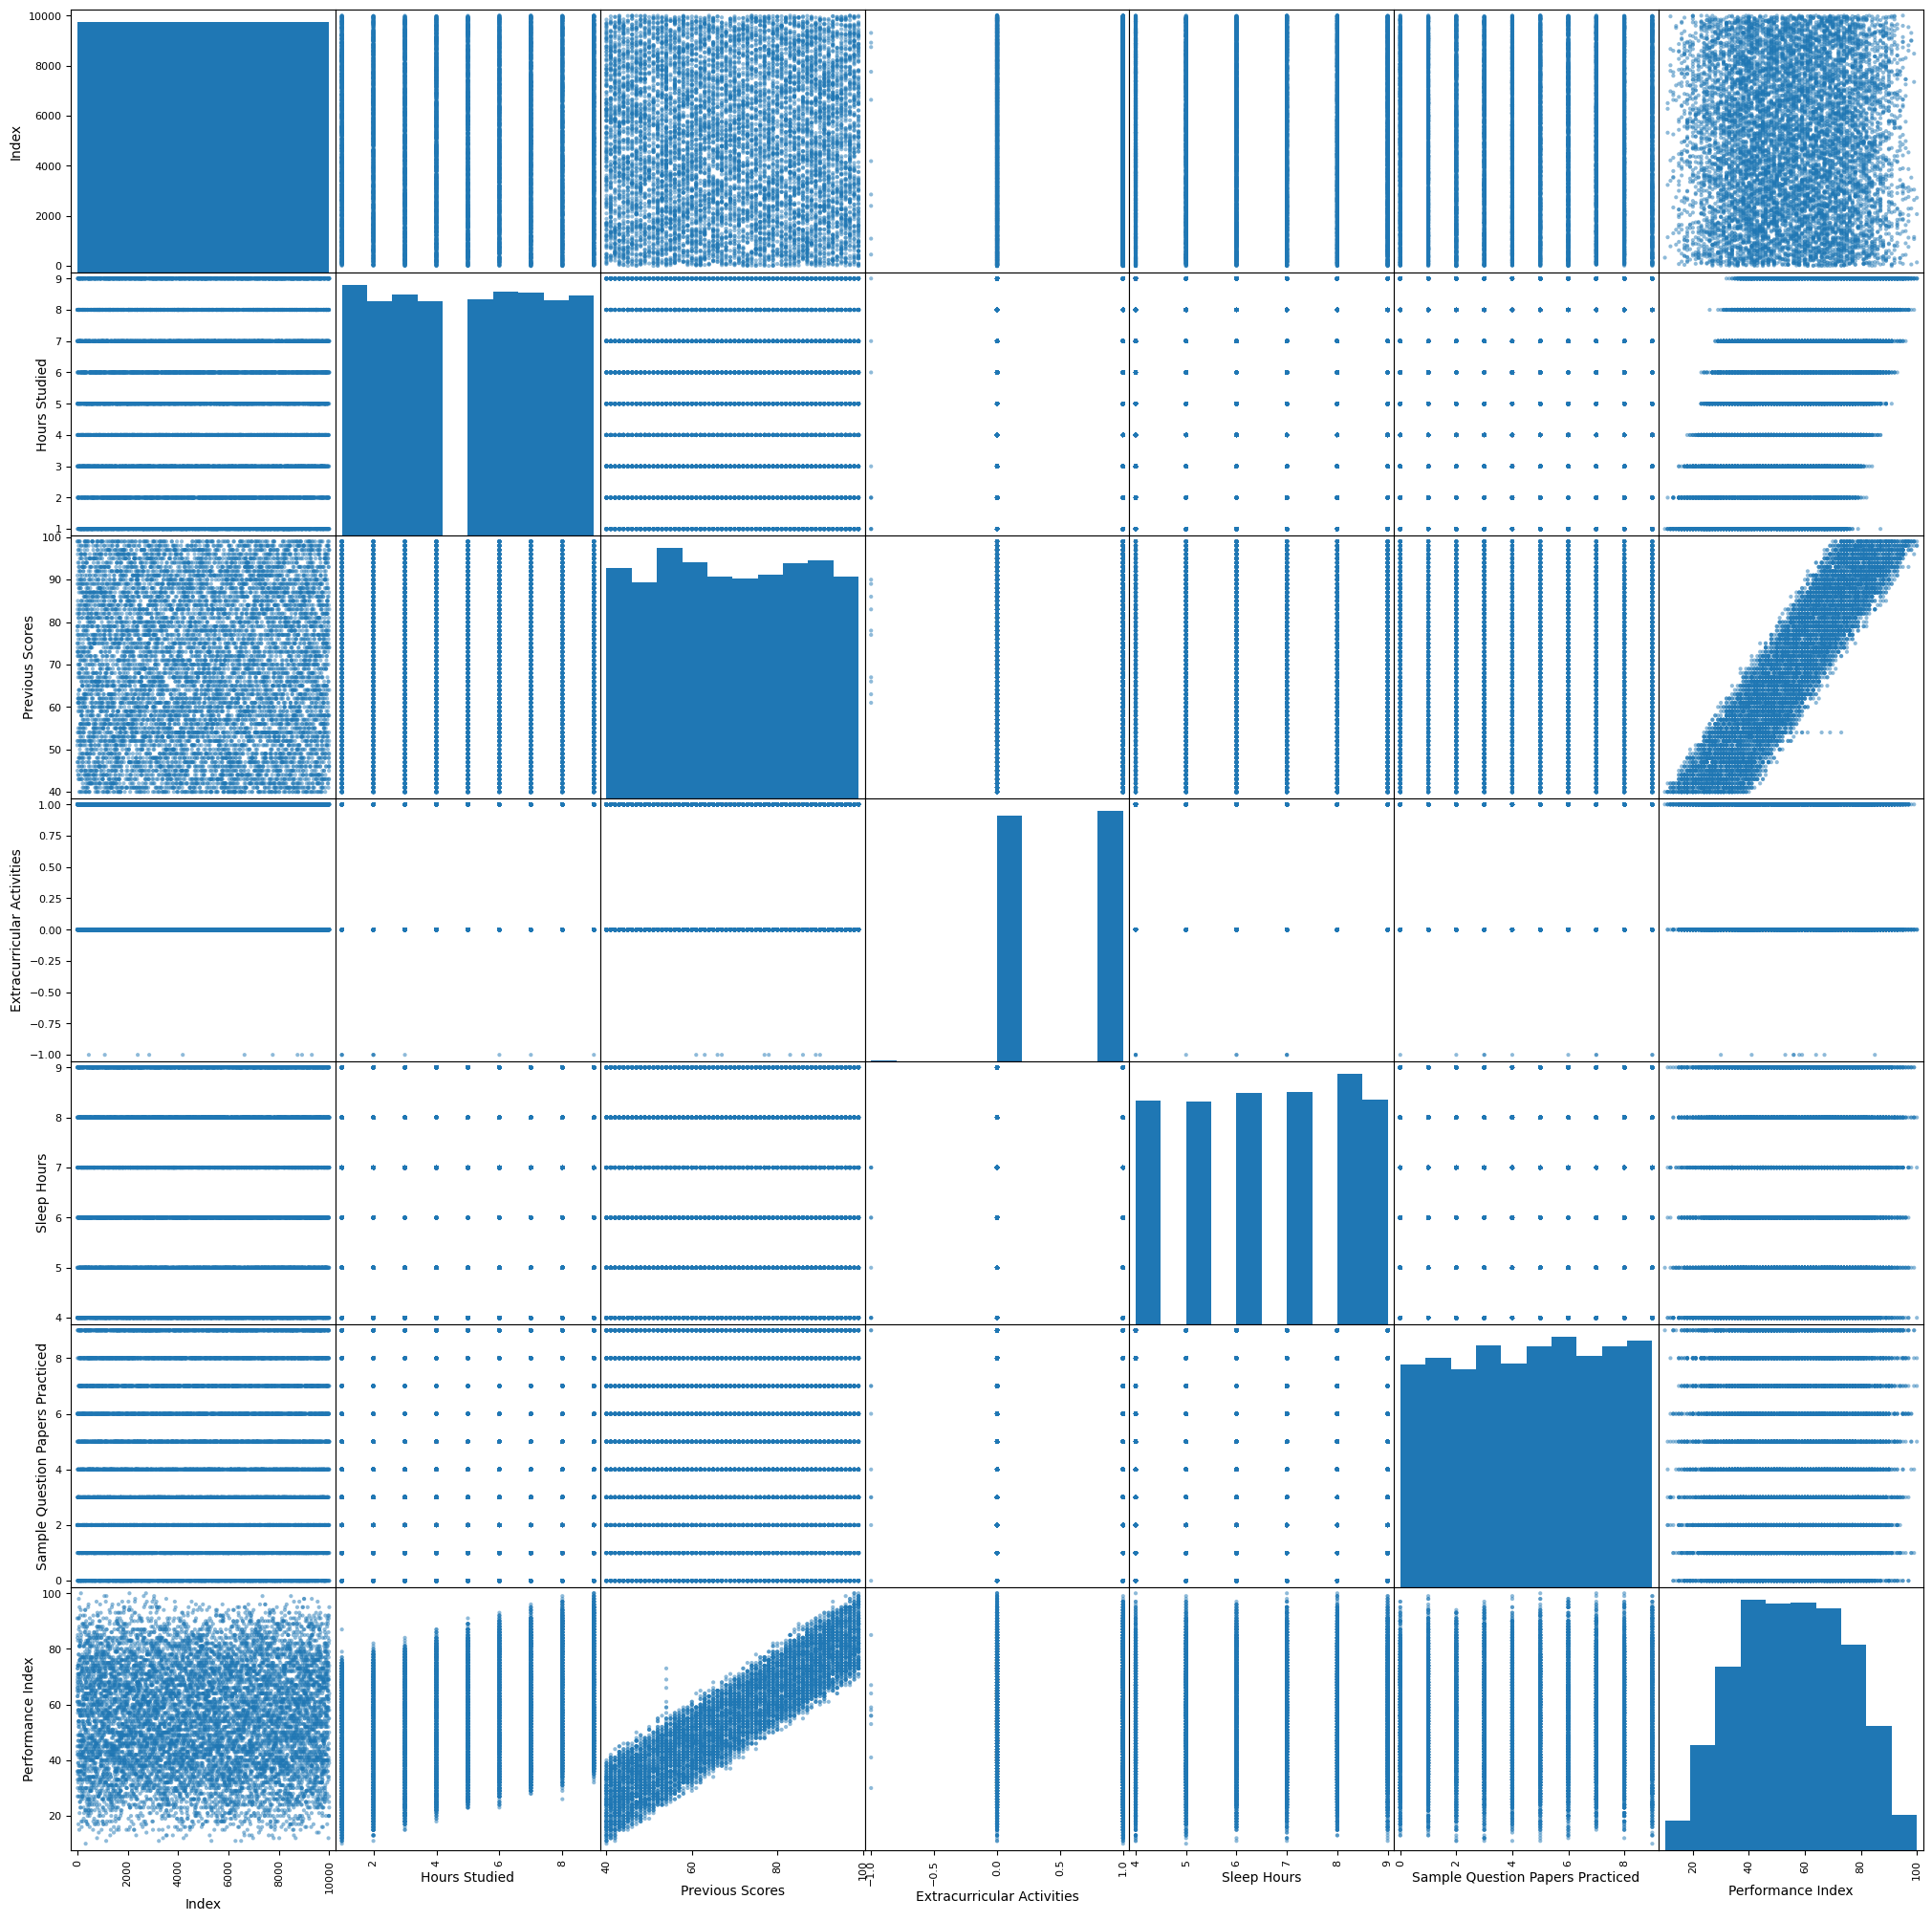

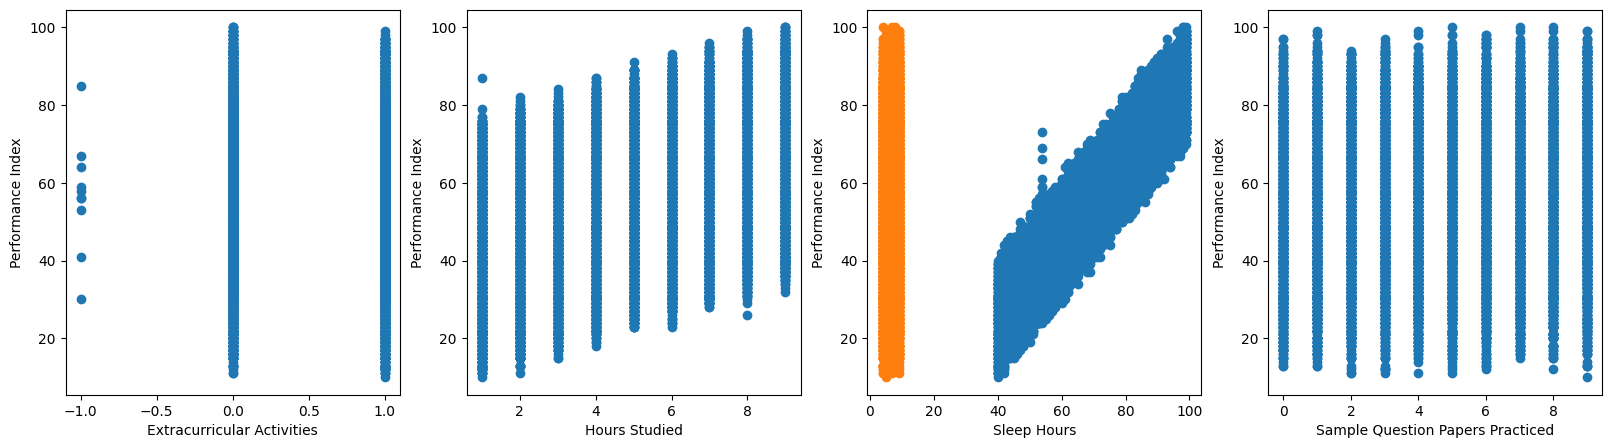

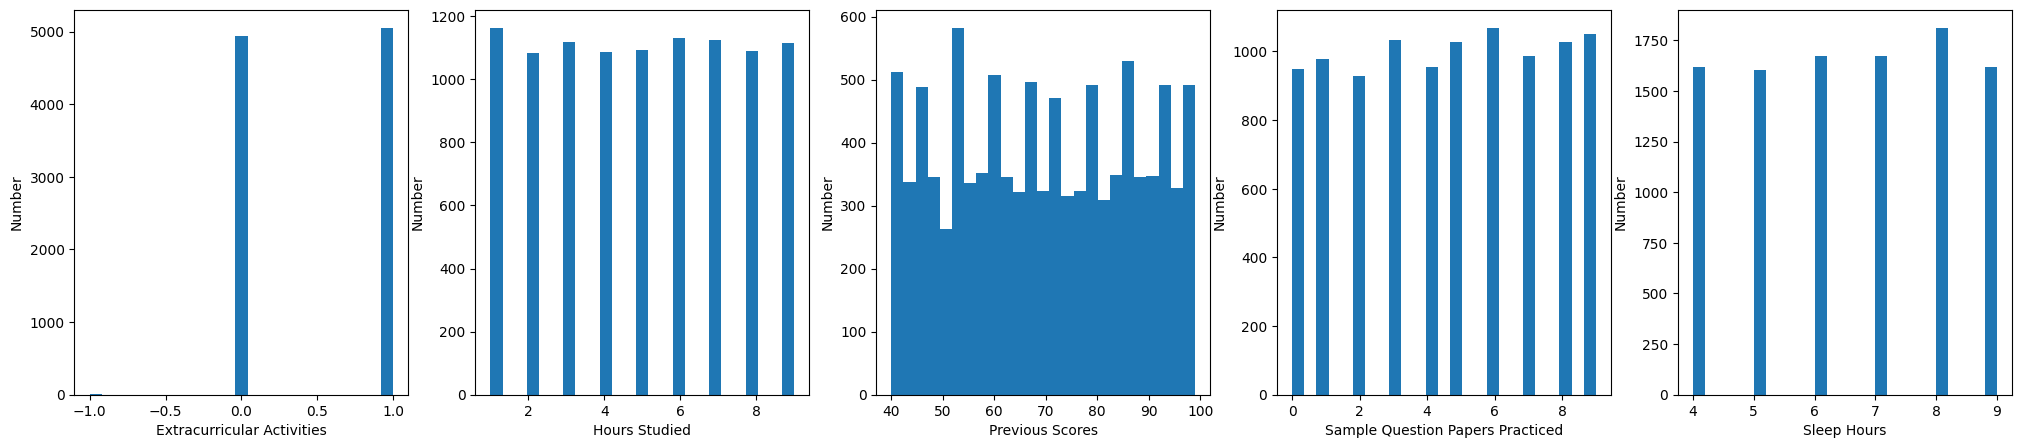

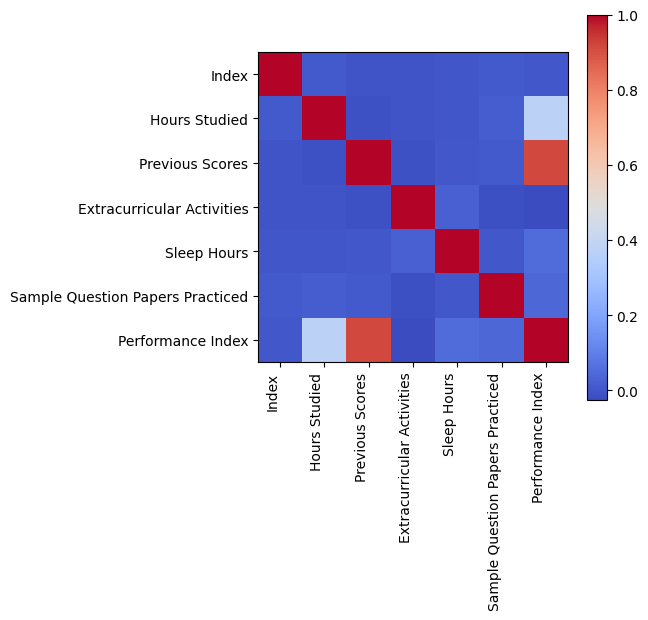

In [5]:
# scatter plot
# first way
from pandas.plotting import scatter_matrix

scatter_matrix(df,figsize=(25,25))
plt.show()

# second way
plt.figure(figsize=(25,5))
plt.subplot(1,5,1)
plt.scatter(df['Extracurricular Activities'],df['Performance Index'])
plt.xlabel('Extracurricular Activities')
plt.ylabel('Performance Index')

plt.subplot(1,5,2)
plt.scatter(df['Hours Studied'],df['Performance Index'])
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')

plt.subplot(1,5,3)
plt.scatter(df['Previous Scores'],df['Performance Index'])
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')

plt.subplot(1,5,4)
plt.scatter(df['Sample Question Papers Practiced'],df['Performance Index'])
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Performance Index')

plt.subplot(1,5,3)
plt.scatter(df['Sleep Hours'],df['Performance Index'])
plt.xlabel('Sleep Hours')
plt.ylabel('Performance Index')

# histogram
plt.figure(figsize=(25,5))

plt.subplot(1,5,1)
plt.hist(df['Extracurricular Activities'],bins=25)
plt.xlabel('Extracurricular Activities')
plt.ylabel('Number')

plt.subplot(1,5,2)
plt.hist(df['Hours Studied'],bins=25)
plt.xlabel('Hours Studied')
plt.ylabel('Number')

plt.subplot(1,5,3)
plt.hist(df['Previous Scores'],bins=25)
plt.xlabel('Previous Scores')
plt.ylabel('Number')

plt.subplot(1,5,4)
plt.hist(df['Sample Question Papers Practiced'],bins=25)
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Number')

plt.subplot(1,5,5)
plt.hist(df['Sleep Hours'],bins=25)
plt.xlabel('Sleep Hours')
plt.ylabel('Number')


# heat map
corr_matrix=df.corr()

plt.figure(figsize=(5,5))
x=plt.imshow(corr_matrix,cmap='coolwarm',interpolation='nearest')
plt.xticks(np.arange(len(corr_matrix.columns)),corr_matrix.columns,rotation=90,ha='right')
plt.yticks(np.arange(len(corr_matrix.columns)),corr_matrix.columns,ha='right')
plt.colorbar(x)

### normalizing numerical data

In [6]:
columns=df.columns
for col in columns:
    mean=df[col].mean()
    std=df[col].std()
    df[col]=(df[col]-mean)/std

print(df.head(20))


       Index  Hours Studied  Previous Scores  Extracurricular Activities  \
0  -1.731791       0.776492         1.704322                   -1.003773   
1  -1.731445      -0.381126         0.724333                    0.988235   
2  -1.731098       1.162364        -1.062706                   -1.003773   
3  -1.730752       0.004746        -1.005059                   -1.003773   
4  -1.730405       0.776492         0.320808                    0.988235   
5  -1.730059      -0.766999         0.493747                    0.988235   
6  -1.729713       0.776492         0.205515                   -1.003773   
7  -1.729366       1.162364        -1.408584                   -1.003773   
8  -1.729020       0.004746         0.436101                    0.988235   
9  -1.728673      -0.381126         1.127858                    0.988235   
10 -1.728327       1.162364         1.243151                    0.988235   
11 -1.727981       1.162364         0.551394                    0.988235   
12 -1.727634

### removing duplicate data

In [7]:
df.drop_duplicates(inplace=True)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Index                             10000 non-null  float64
 1   Hours Studied                     10000 non-null  float64
 2   Previous Scores                   10000 non-null  float64
 3   Extracurricular Activities        10000 non-null  float64
 4   Sleep Hours                       10000 non-null  float64
 5   Sample Question Papers Practiced  10000 non-null  float64
 6   Performance Index                 10000 non-null  float64
dtypes: float64(7)
memory usage: 547.0 KB
None


## Step 2

### MSE loss

In [8]:
def MSE_for_linear_regression(y,X,w):
    m=y.shape[0]
    return (1/(2*m))*(y-X@w).T@(y-X@w)
    #return np.sum((y-X@w)**2)/(2*m)

def MSE_gradient_for_linear_regression(y,X,w):
    m=y.shape[0]
    return (1/m)*X.T@(y-X@w)

### MAE loss

In [9]:
def MAE_for_linear_regression(y,X,w):
    m=y.shape[0]
    return (1/m)*np.sum(np.abs(y-X@w))

def MAE_gradient_for_linear_regression(y,X,w):
    m=y.shape[0]
    temp=np.sign(y-X@w)
    zero_count=len(temp)-np.count_nonzero(temp) # computing number of times we need to use the subgradient
    temp=np.where(temp == 0,1,temp) #subgradient
    return (1/m)*X.T@temp

### GD

In [10]:
def GD(num_epoch,y,X,w,loss_func,losses,lr=0.1):
    for epoch in range(num_epoch):
        if loss_func == 'mse':
            w=w-lr*MSE_gradient_for_linear_regression(y,X,w)
            losses.append(MSE_for_linear_regression(y,X,w)[0][0])

        elif loss_func=='mae':
            w=w-lr*MAE_gradient_for_linear_regression(y,X,w)
            losses.append(MAE_for_linear_regression(y,X,w))

    
    return w,losses


### mini-batch GD

In [11]:
def mini_batch_GD(num_epoch,batch_size,y,X,w,loss_func,losses,lr=0.1):
    shuffled_indices=np.random.permutation(len(y))
    X_shuffled=X[shuffled_indices]
    y_shuffled=y[shuffled_indices]
    num_batch=int(np.ceil(len(y)/batch_size))

    for epoch in range(num_epoch):
        for iteration in range(num_batch):
            begin=iteration*batch_size
            end=begin+batch_size

            batch_X=X_shuffled[begin:end]
            batch_y=y_shuffled[begin:end]

            if loss_func=='mse':
                w=w-lr*MSE_gradient_for_linear_regression(batch_y,batch_X,w)
                

            elif loss_func=='mae':
                w=w-lr*MAE_gradient_for_linear_regression(batch_y,batch_X,w)
        
        if loss_func=='mse':
            losses.append(MSE_for_linear_regression(y_shuffled,X_shuffled,w)[0][0])

        elif loss_func=='mae':
            losses.append(MAE_for_linear_regression(y_shuffled,X_shuffled,w))

    return w,losses

            



### SGD

In [12]:
# SGD = mini-batch GD with batch size equal to 1

def SDG(num_epoch,y,X,w,loss_func,losses,lr=0.1):
    
    batch_size=1
    return mini_batch_GD(num_epoch,batch_size,y,X,w,loss_func,losses,lr)

### train & predict functions

In [13]:
def train(optimizer,batch_size,num_epoch,y,X,w,loss_func,losses,lr):
    if optimizer=='gd':
        w,losses=GD(num_epoch,y,X,w,loss_func,losses,lr)

    elif optimizer=='mini-batch gd':
        w,losses=mini_batch_GD(num_epoch,batch_size,y,X,w,loss_func,losses,lr)

    elif optimizer=='sgd':
        w,losses=SDG(num_epoch,y,X,w,loss_func,losses,lr)
    

    return w,losses


def predict(X,w):
    return X@w

### optimizing hyper parameters

In [14]:
def grid_search_for_lr(X,y,w,optimizer,num_epoch,loss_func):
    learning_rates=[0.001,0.01,0.1,0.25,0.5,1]
    best_lr=0
    min_loss=float('inf')
    losses=[]
    for lr in learning_rates:
        if optimizer=='gd':
            w,losses=train(optimizer,len(y),num_epoch,y,X,w,loss_func,losses,lr)

        elif optimizer=='mini-batch gd':
            w,losses=train('mini-batch gd',32,num_epoch,y,X,w,'mse',losses,lr)

        #y_pred=predict(X,w)

        if loss_func=='mse':
            loss=MSE_for_linear_regression(y,X,w)[0][0]

        elif loss_func=='mae':
            loss=MAE_for_linear_regression(y,X,w)


        if loss < min_loss:
            min_loss=loss
            best_lr=lr

    return best_lr

        



### training model

In [ ]:


mse_losses_gd=[]
mse_losses_mini_batch_gd=[]

num_epoch=100


y=df.loc[:,'Performance Index'].to_numpy()
y=y.reshape((10000,1))

df.drop('Performance Index',axis=1,inplace=True)
X=df.loc[:,'Hours Studied':'Sample Question Papers Practiced'].to_numpy()


X=np.c_[np.ones((len(y),1)),X]

w=np.zeros((X.shape[1],1))

lr1=grid_search_for_lr(X,y,w,'gd',num_epoch,'mse')

w1,mse_losses_gd=train('gd',len(y),num_epoch,y,X,w,'mse',mse_losses_gd,0.1)

w=np.zeros((X.shape[1],1))
lr2=grid_search_for_lr(X,y,w,'mini-batch gd',num_epoch,'mse')

w2,mse_losses_mini_batch_gd=train('mini-batch gd',32,num_epoch,y,X,w,'mse',mse_losses_mini_batch_gd,0.1)




### cost-epoch plot

In [ ]:
# mse_losses_mini_batch_gd.reverse()
# mse_losses_gd.reverse()

xx=np.arange(1,num_epoch+1)
plt.plot(xx,mse_losses_gd,label='GD optimizer')
plt.plot(xx,mse_losses_mini_batch_gd,label='mini-batch GD optimizer')
plt.xlabel('Epoch')
plt.ylabel('Cost')

plt.legend()
plt.show()

### explaination

The convergence speed in mini batch GD is faster, but the final cost will be lower than in batch gradient descent. The reason for more distortions in the minibatch gradient descent algorithm is that in each iteration, the parameters are updated based on a mini batch data, and the parameters are updated in such a way that the error on that mini batch decreases but may increase on other mini batches, which leads to an increase in the average error on the entire data set. So the graph sometimes goes up and has more fluctuations, but overall it converges towards the optimal point.

## Step 3

### GD with parameters random initialization 

In [ ]:
w_random=np.random.randn(X.shape[1])
w_random=w_random.reshape((6,1))
print('random parameters: ',w_random)

# training model with random parameter initialization
losses=[]
w_final,losses=train('gd',len(y),num_epoch,y,X,w_random,'mse',losses,0.1)


xx=np.arange(1,num_epoch+1)
plt.plot(xx,losses)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()


### comparison

In iterative optimization methods such as gradient descent, if all parameters have the same initial value such as zero, the model has given equal importance to all features and all parameters will have the same gradients during optimization and will change equally. Therefore, random parameter values ​​are better.

### train model with SGD & MAE

In [ ]:
w_random=np.random.randn(X.shape[1])
w_random=w_random.reshape((6,1))
losses_=[]

w_final , losses_=train('sgd',1,num_epoch,y,X,w_random,'mae',losses_,0.1)

xx=np.arange(1,num_epoch+1)
plt.plot(xx,losses_)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

### comparison & explaination

The mean square error function tries to reduce all parameters to prevent overfitting the model, but usually does not make them zero. However, the mean absolute error function tries to make a good number of parameters zero and remove a number of features, thereby preventing overfitting the model. The stochastic gradient descent optimizer function also has more fluctuations than the batch gradient descent and the minibatch gradient descent.
In MAE cost function, at points where the cost function is not differentiable, a subgradient equal to 1 is used.

### large learning rate

In [ ]:
lr=5
losses_=[]
w_final , losses_=train('gd',len(y),num_epoch,y,X,w_random,'mse',losses_,lr)

xx=np.arange(1,num_epoch+1)
plt.plot(xx,losses_)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

If the learning rate is too high, the model will diverge.

## Step 4

In [20]:
def MSE_loss_with_ridge(y,X,w,lambda_):
    m=y.shape[0]
    return (1/(2*m))*(y-X@w).T@(y-X@w) + lambda_*w.T@w

def MSE_with_ridge_gradient(y,X,w,lambda_):
    m=y.shape[0]
    return (1/m)*X.T@(y-X@w)+2*lambda_*w

def GD_with_regularization(num_epoch,y,X,w,losses,lambda_,lr=0.1):
    for epoch in range(num_epoch):
        
        w=w-lr*MSE_with_ridge_gradient(y,X,w,lambda_)
        losses.append(MSE_loss_with_ridge(y,X,w,lambda_)[0][0])

    return w,losses



def train_with_regularization(num_epoch,y,X,w,losses,lambda_,lr):
    w,losses=GD_with_regularization(num_epoch,y,X,w,losses,lambda_,lr)

    return w,losses



def grid_search_for_lambda(X,y,w,num_epoch):
    lambdas=[0.001,0.01,0.1,0.5,10]
    best_lambda=0
    min_loss=float('inf')
    losses=[]
    for lambda_ in lambdas:
       
        w,losses=train_with_regularization(num_epoch,y,X,w,losses,lambda_,0.1)

        loss=MSE_with_ridge_gradient(y,X,w,lambda_)[0][0]

 
        if loss < min_loss:
            min_loss=loss
            best_lambda=lambda_

    return best_lambda

In [ ]:
import itertools

cols=['Hours Studied','Previous Scores','Extracurricular Activities','Sleep Hours','Sample Question Papers Practiced']

# quadratic features
for col in cols:
    df[f'{col}_quad']=df[col].pow(2)

for col1,col2 in itertools.combinations(cols,2):
    df[f'{col1}_{col2}_quad']=df[col1]*df[col2]

# normalization
columns=df.columns
for col in columns:
    mean=df[col].mean()
    std=df[col].std()
    df[col]=(df[col]-mean)/std


X=df.loc[:,'Hours Studied':'Sleep Hours_Sample Question Papers Practiced_quad'].to_numpy()
X=np.c_[np.ones((len(y),1)),X]


w_random=np.random.randn(X.shape[1])
w_random=w_random.reshape((X.shape[1],1))

losses=[]

w_final,losses=train_with_regularization(num_epoch,y,X,w_random,losses,0.5,lr)


xx=np.arange(1,num_epoch+1)
plt.plot(xx,losses)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()